In [3]:
!pip uninstall numpy -y
!pip install numpy==1.26.4

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.


In [ ]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio

Found existing installation: torch 2.2.2
Uninstalling torch-2.2.2:


In [ ]:
!pip install grad-cam

In [143]:
import torch
import torch.nn as nn
import timm
import numpy as np
import cv2
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

from facenet_pytorch import MTCNN
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [144]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [145]:
class DeepfakeModel(nn.Module):

    def __init__(self):
        super().__init__()

        self.cnn = timm.create_model(
            "efficientnet_b0",
            pretrained=False,
            num_classes=0
        )

        self.lstm = nn.LSTM(
            input_size=1280,
            hidden_size=256,
            num_layers=1,
            batch_first=True
        )

        self.fc = nn.Linear(256,1)

    def forward(self,x):

        B,T,C,H,W = x.shape

        x = x.view(B*T,C,H,W)

        features = self.cnn(x)

        features = features.view(B,T,-1)

        lstm_out,_ = self.lstm(features)

        out = lstm_out[:,-1,:]

        out = self.fc(out)

        return out

In [147]:
model = DeepfakeModel().to(DEVICE)

model.load_state_dict(
    torch.load(
        "/mnt/d/deepfake/tf-gpu-env/complete_project/models/deepfake_model_temporal.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Model Loaded Successfully")

Model Loaded Successfully


In [148]:
mtcnn = MTCNN(
    image_size=160,
    margin=10,
    device=DEVICE
)

In [149]:
target_layer = model.cnn.blocks[-1]

cam = GradCAM(
    model=model.cnn,
    target_layers=[target_layer]
)

(-0.5, 223.5, 223.5, -0.5)

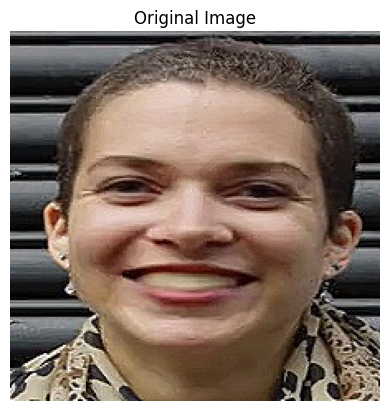

In [198]:
image_path = "/mnt/d/deepfake/tf-gpu-env/complete_project/faces_train_test/val/fake/01_02__outside_talking_still_laughing__YVGY8LOK_0_0.jpg"

img = Image.open(image_path).convert("RGB")

plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

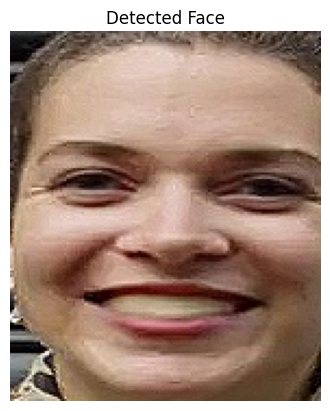

In [199]:
boxes, probs = mtcnn.detect(img)

if boxes is None:
    print("No face detected")
else:
    x1,y1,x2,y2 = boxes[0].astype(int)

    face_crop = img.crop((x1,y1,x2,y2))

    plt.imshow(face_crop)
    plt.title("Detected Face")
    plt.axis("off")

In [200]:
transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

input_tensor = transform(face_crop).unsqueeze(0).to(DEVICE)

In [201]:
grayscale_cam = cam(input_tensor=input_tensor)

heatmap = grayscale_cam[0]

(-0.5, 159.5, 159.5, -0.5)

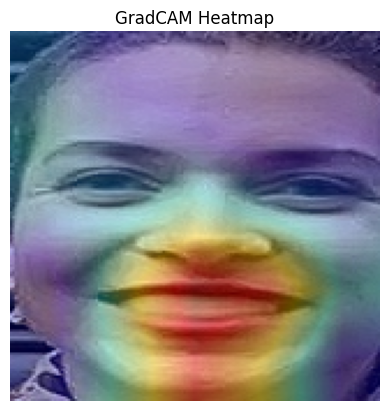

In [202]:
face_resized = face_crop.resize((160,160))

face_np = np.array(face_resized)/255.0

visualization = show_cam_on_image(
    face_np,
    heatmap,
    use_rgb=True,
    image_weight=0.7
)

plt.imshow(visualization)
plt.title("GradCAM Heatmap")
plt.axis("off")

In [203]:
heatmap_norm = cv2.normalize(
    heatmap,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

_, thresh = cv2.threshold(
    heatmap_norm,
    200,
    255,
    cv2.THRESH_BINARY
)

In [209]:
contours, _ = cv2.findContours(
    thresh,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

contours = sorted(contours, key=cv2.contourArea, reverse=True)

In [207]:
top_k = 3

img_box = (face_np*255).astype(np.uint8)

for contour in contours[:top_k]:

    x,y,w,h = cv2.boundingRect(contour)

    cv2.rectangle(
        img_box,
        (x,y),
        (x+w,y+h),
        (255,0,0),
        2
    )

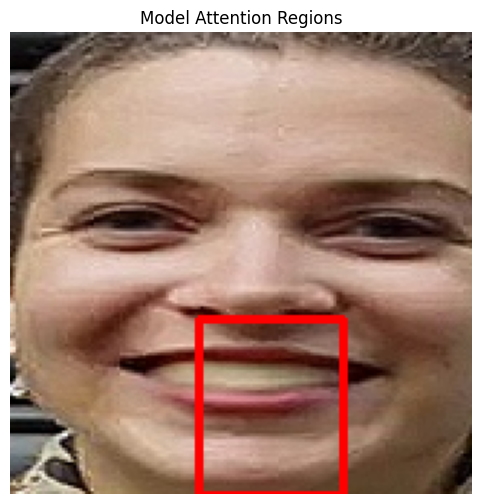

In [210]:
plt.figure(figsize=(6,6))

plt.imshow(img_box)

plt.title("Model Attention Regions")

plt.axis("off")

plt.show()